In [1]:
!pip install -q peft transformers torch pandas tqdm accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 41.1 MB/s eta 0:00:00:00:0100:01


In [17]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
from tqdm import tqdm
from scipy.optimize import minimize
from sklearn.metrics import log_loss, accuracy_score
from sklearn.metrics import accuracy_score, f1_score
from scipy.optimize import differential_evolution
from sklearn.metrics import accuracy_score
import json
from pathlib import Path

In [31]:
# Configuration
PATHS = {
    'test_csv': "/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/train.csv",
    'deberta': "/kaggle/input/kdsh26-deberta-v3-base-fine-tune-model/deberta-v3-base-nli/checkpoint-40",
    'qwen_v2': "/kaggle/input/kdsh26-qwen2-5-7b-instruct-fine-tune-model/qwen2.5-7b-books-lora-cls/checkpoint-10000",
    'qwen_v1': "/kaggle/input/kdsh26-qwen2-5-7b-instruct-fine-t-model-checkpoint/qwen2.5-7b-books-lora-cls/kaggle/working/qwen2.5-7b-books-lora-cls/checkpoint-5000",
    'output_ensemble': "submission.csv"
}

TEST_PATH = "/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/train.csv"
MC_CONS_PATH = "/kaggle/input/kdsh26-jsonl-file-characters-2/Jsonl_file_chars/monte_cristo/monte_cristo_constraints_updated_2.jsonl"
CA_CONS_PATH = "/kaggle/input/kdsh26-jsonl-file-characters-2/Jsonl_file_chars/castaways/castaways_constraints_filled.jsonl"

device = "cuda" if torch.cuda.is_available() else "cpu"

In [28]:
def load_constraints(path):
    mapping = {}
    with Path(path).open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            key = (obj["book_name"], obj["character"])
            mapping[key] = obj.get("constraints", [])
    return mapping

def constraint_to_sentence(book, char, c):
    dim, val = c["dimension"], c["value"]
    if dim == "health_state":
        return f"In {book}, {char} is {val}."
    elif dim == "family_role":
        return f"In {book}, {char} has family role: {val}."
    elif dim == "role":
        return f"In {book}, {char} is described as {val}."
    elif dim == "geographic_expertise":
        return f"{char} is familiar with {val}."
    elif dim == "criminal_history":
        return f"{char} has criminal history: {val}."
    else:
        return f"{dim}: {val}."

def build_context(book, char, max_cons=6):
    cons = constraints.get((book, char), [])
    return " ".join(
        constraint_to_sentence(book, char, c)
        for c in cons[:max_cons]
    )


In [32]:
mc_constraints = load_constraints(MC_CONS_PATH)
ca_constraints = load_constraints(CA_CONS_PATH)
constraints = {**mc_constraints, **ca_constraints}

In [23]:
test_df["context"] = test_df.apply(
    lambda r: build_context(r["book_name"], r["char"]), axis=1
)

In [34]:
def load_models():
    print("--- Loading DeBERTa ---")
    deb_tk = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
    deb_mdl = AutoModelForSequenceClassification.from_pretrained(PATHS['deberta'], num_labels=2, local_files_only=True).to(device).eval()
    
    print("--- Loading Qwen Base and Adapters ---")
    q_tk = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
    base_model = AutoModelForSequenceClassification.from_pretrained(
        "Qwen/Qwen2.5-7B-Instruct", 
        num_labels=2, 
        torch_dtype=torch.float16, 
        device_map="auto"
    )
    
    # Load Qwen v2 as primary adapter
    qwen_mdl = PeftModel.from_pretrained(base_model, PATHS['qwen_v2'], adapter_name="v2")
    # Load Qwen v1 as additional adapter to save memory
    qwen_mdl.load_adapter(PATHS['qwen_v1'], adapter_name="v1")
    qwen_mdl.eval()
    
    return (deb_tk, deb_mdl), q_tk, qwen_mdl

def get_probs_fixed(df, tk, mdl, model_type="qwen", adapter_name=None):
    probs_list = []
    cols = df.columns.tolist()

    ctx_col = next((c for c in ['context', 'context_for_inference', 'full_text'] if c in cols), None)
    stmt_col = next((c for c in ['content', 'statement'] if c in cols), None)

    if not ctx_col or not stmt_col:
        raise KeyError(f"Could not find required columns. Available: {cols}")

    print(f"Using '{ctx_col}' as Premise and '{stmt_col}' as Hypothesis.")

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Inference {model_type}"):
        premise = str(row[ctx_col])
        hypothesis = str(row[stmt_col])

        # SAME TEMPLATE AS TRAINING
        if model_type == "deberta":
            text = f"Premise: {premise}\nHypothesis: {hypothesis}"
        else:
            if adapter_name:
                mdl.set_adapter(adapter_name)
            text = f"Premise: {premise}\nHypothesis: {hypothesis}"

        inputs = tk(
            text,
            max_length=512,
            truncation=True,
            return_tensors="pt",
            padding="max_length"
        ).to(device)

        with torch.no_grad():
            logits = mdl(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

        # class 1 = contradict
        probs_list.append(probs[1])

    return np.array(probs_list)


In [35]:
(deb_tk, deb_mdl), q_tk, qwen_mdl = load_models()

--- Loading DeBERTa ---


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


--- Loading Qwen Base and Adapters ---


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-7B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [36]:
# --- EXECUTION ---
test_df = pd.read_csv(PATHS['test_csv'])

# CRITICAL: rebuild context exactly like LLM inference
test_df["context"] = test_df.apply(
    lambda r: build_context(r["book_name"], r["char"]),
    axis=1
)

y_true_numeric = test_df['label'].map({"consistent": 0, "contradict": 1}).values

# 1. Get Probabilities
p_deb = get_probs_fixed(test_df, deb_tk, deb_mdl, "deberta")
p_qw2 = get_probs_fixed(test_df, q_tk, qwen_mdl, "qwen_v2", adapter_name="v2")
p_qw1 = get_probs_fixed(test_df, q_tk, qwen_mdl, "qwen_v1", adapter_name="v1")


pred_matrix = np.vstack([p_deb, p_qw2, p_qw1]).T

Using 'context' as Premise and 'content' as Hypothesis.


Inference deberta: 100%|██████████| 80/80 [00:00<00:00, 88.14it/s]


Using 'context' as Premise and 'content' as Hypothesis.


Inference qwen_v2: 100%|██████████| 80/80 [00:03<00:00, 24.09it/s]


Using 'context' as Premise and 'content' as Hypothesis.


Inference qwen_v1: 100%|██████████| 80/80 [00:02<00:00, 31.32it/s]


In [37]:
def objective(w):
    weights = w / (np.sum(w) + 1e-8)
    preds = (np.dot(pred_matrix, weights) > 0.5).astype(int)
    return 1.0 - accuracy_score(y_true_numeric, preds)

In [38]:
# Global search for the best weights
res = differential_evolution(objective, bounds=[(0, 1)]*3, tol=1e-7)
best_w = res.x / np.sum(res.x)

# 3. Final Outputs
final_probs = np.dot(pred_matrix, best_w)
final_preds = (final_probs > 0.5).astype(int)

print(f"Optimal Weights: {best_w}")
print(f"Final Accuracy: {accuracy_score(y_true_numeric, final_preds):.4f}")

# Save results
test_df['label'] = ["consistent" if p == 0 else "contradict" for p in final_preds]
test_df[['id', 'label']].to_csv("submission.csv", index=False)

Optimal Weights: [0.98915654 0.00906864 0.00177482]
Final Accuracy: 0.8875


In [39]:
pred_df = pd.read_csv("/kaggle/working/submission.csv")
print(pred_df.head())

    id       label
0   46  consistent
1  137  contradict
2   74  consistent
3  109  consistent
4  104  consistent


Accuracy: 0.8875 (71/80)
F1 Score (Macro): 0.8676
F1 Score (Weighted): 0.8817

Classification Report:
              precision    recall  f1-score   support

  consistent       0.85      1.00      0.92        51
  contradict       1.00      0.69      0.82        29

    accuracy                           0.89        80
   macro avg       0.93      0.84      0.87        80
weighted avg       0.90      0.89      0.88        80



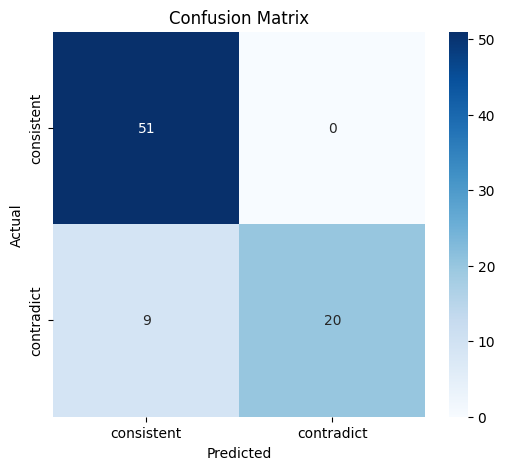

In [40]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare Lists
# Ground Truth (from the dataframe you loaded as TEST_PATH)
act_tr = pd.read_csv("/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/train.csv")
y_true = act_tr["label"] 

# Predictions (from your submission dataframe)
y_pred = pred_df["label"]

# 2. Calculate Metrics
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

# 3. Print Results
print(f"Accuracy: {acc:.4f} ({np.sum(y_true == y_pred)}/{len(y_true)})")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# 4. (Optional) Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred, labels=["consistent", "contradict"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["consistent", "contradict"], 
            yticklabels=["consistent", "contradict"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()